<a href="https://colab.research.google.com/github/ibuscio/Machine-Learning/blob/main/Practico0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importamos algunas librearias a utilizar
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')
import pandas as pd

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
data = pd.read_csv('/content/Pearson_Crab_Data.csv')

In [6]:
print(data)

     ratio  freq
0   0.5835     1
1   0.5875     3
2   0.5915     5
3   0.5955     2
4   0.5995     7
5   0.6035    10
6   0.6075    13
7   0.6115    19
8   0.6155    20
9   0.6195    25
10  0.6235    40
11  0.6275    31
12  0.6315    60
13  0.6355    62
14  0.6395    54
15  0.6435    74
16  0.6475    84
17  0.6515    86
18  0.6555    96
19  0.6595    85
20  0.6635    75
21  0.6675    47
22  0.6715    43
23  0.6755    24
24  0.6795    19
25  0.6835     9
26  0.6875     5
27  0.6915     0
28  0.6955     1


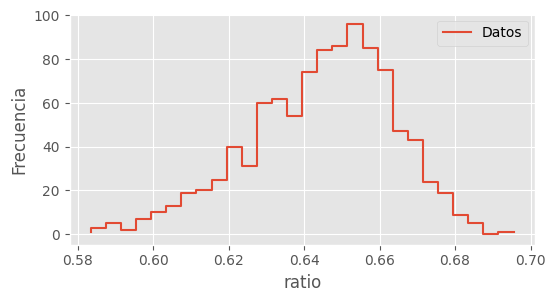

In [7]:
# Graficamos las frecuencias
plt.figure(figsize=(6, 3))
plt.step(x=data['ratio'],y=data['freq'], label='Datos')
plt.legend()
plt.xlabel('ratio')
plt.ylabel('Frecuencia')
plt.show()


In [8]:
data['freq_rel'] = data['freq']/data['freq'].sum()

In [ ]:
data.head()

,ratio,freq,freq_rel
0,0.5835,1,0.001
1,0.5875,3,0.003
2,0.5915,5,0.005
3,0.5955,2,0.002
4,0.5995,7,0.007


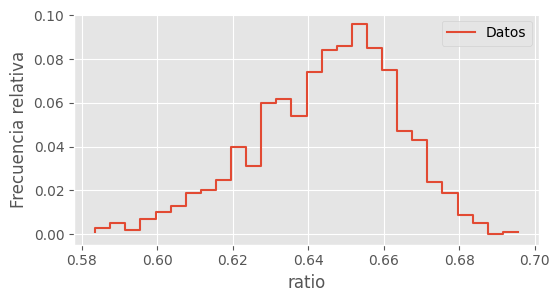

In [11]:
# Graficamos las frecuencias relativas
plt.figure(figsize=(6, 3))
plt.step(x=data['ratio'],y=data['freq_rel'], label='Datos')
plt.legend()
plt.xlabel('ratio')
plt.ylabel('Frecuencia relativa')
plt.show()

In [ ]:
# Calculamos la longitud del intervalo en el rango de ratio
data['delta_ratio'] = None

In [16]:
data['delta_ratio'] = data['ratio'].diff()
# The first value will be NaN, we can fill it with the next difference or a specific value if needed
# For simplicity, let's fill the first NaN with the average of the rest or 0 if it doesn't matter for further calculations
data['delta_ratio'] = data['delta_ratio'].fillna(data['delta_ratio'].iloc[1]) # Fill first NaN with the second value


In [15]:
# Visualizamos nuevamente los datos
display(data.head())
display(data.tail())

,ratio,freq,freq_rel,delta_ratio
0,0.5835,1,0.001,0.004
1,0.5875,3,0.003,0.004
2,0.5915,5,0.005,0.004
3,0.5955,2,0.002,0.004
4,0.5995,7,0.007,0.004


,ratio,freq,freq_rel,delta_ratio
24,0.6795,19,0.019,0.004
25,0.6835,9,0.009,0.004
26,0.6875,5,0.005,0.004
27,0.6915,0,0.000,0.004
28,0.6955,1,0.001,0.004


In [17]:
print(data.columns)

Index(['ratio', 'freq', 'freq_rel', 'delta_ratio'], dtype='object')


In [ ]:
# Creamos una columna de densidad = (frecuencia reativa) / (longitud)
data['densidad'] = None

In [19]:
data['densidad'] = data['freq_rel'] / data['delta_ratio']

In [20]:
print(data.columns)

Index(['ratio', 'freq', 'freq_rel', 'delta_ratio', 'densidad'], dtype='object')


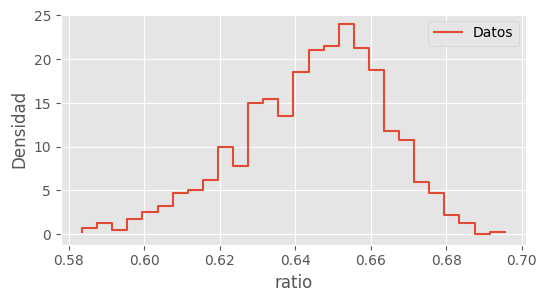

In [22]:
# Graficamos la densidad
plt.figure(figsize=(6, 3))
plt.step(x=data['ratio'],y=data['densidad'], label='Datos')
plt.legend()
plt.xlabel('ratio')
plt.ylabel('Densidad')
plt.show()

In [12]:
from scipy.stats import norm

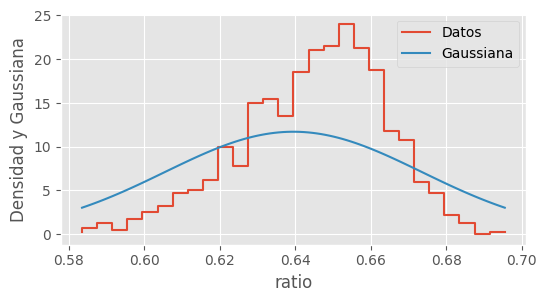

In [27]:
mu = data['ratio'].mean()
sigma = data['ratio'].std()

# Graficamos la densidad junto con la gaussiana
plt.figure(figsize=(6, 3))
plt.step(x=data['ratio'],y=data['densidad'], label='Datos')
r = np.linspace(data['ratio'].min(), data['ratio'].max(), 100)
plt.plot(r, norm.pdf(r, mu, sigma), label='Gaussiana')
plt.legend()
plt.xlabel('ratio')
plt.ylabel('Densidad y Gaussiana')
plt.show()

In [34]:
# Definimos una mezcla de dos gaussianas
def gauss_mixture(x, mu1, mu2, sigma1, sigma2, pi):
  return pi * norm.pdf(x, mu1, sigma1) + (1 - pi) * norm.pdf(x, mu2, sigma2)

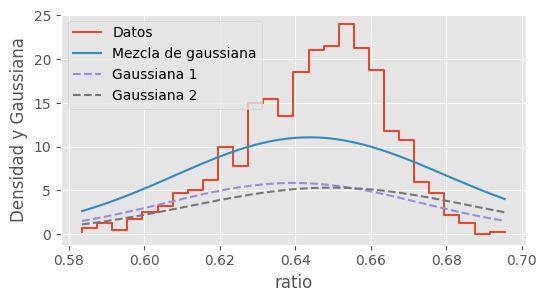

In [35]:
pi = 0.5 # Mixing coefficient, typically between 0 and 1
mu1 =  data['ratio'].mean()
sigma1 = data['ratio'].std()
mu2 =  data['ratio'].mean() + 0.01 # Slightly shifted mean for the second Gaussian
sigma2 = data['ratio'].std() * 1.1 # Slightly different std for the second Gaussian

# Graficamos la densidad junto con la mezcla de gaussiana
plt.figure(figsize=(6, 3))
plt.step(x=data['ratio'],y=data['densidad'], label='Datos')
r = np.linspace(data['ratio'].min(), data['ratio'].max(), 100)
plt.plot(r, gauss_mixture(r, mu1, mu2, sigma1, sigma2, pi), label='Mezcla de gaussiana')
plt.plot(r, pi*norm.pdf(r, mu1, sigma1), label='Gaussiana 1', linestyle='--')
plt.plot(r, (1-pi)*norm.pdf(r, mu2, sigma2), label='Gaussiana 2', linestyle='--')
plt.legend()
plt.xlabel('ratio')
plt.ylabel('Densidad y Gaussiana')
plt.show()

In [31]:
from scipy.stats import kstest
from scipy.stats import norm

# Reconstruct individual data points from 'ratio' and 'freq'
# This creates a flat list where each 'ratio' value appears 'freq' times.
data_points = []
for r_val, freq_val in zip(data['ratio'], data['freq']):
    data_points.extend([r_val] * freq_val)

# Convert to a numpy array for statistical testing
data_points = np.array(data_points)

# Perform the Kolmogorov-Smirnov test
# We compare the empirical distribution of data_points to a normal distribution
# with the previously calculated mean (mu) and standard deviation (sigma).
statistic, p_value = kstest(data_points, 'norm', args=(mu, sigma))

print(f"Kolmogorov-Smirnov Test Statistic: {statistic:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpret the results
alpha = 0.05 # Significance level
if p_value > alpha:
    print(f"Based on the p-value ({p_value:.4f} > {alpha}), we do not reject the null hypothesis.\nThis suggests that the data likely follows a Gaussian distribution.")
elif p_value <= alpha:
    print(f"Based on the p-value ({p_value:.4f} <= {alpha}), we reject the null hypothesis.\nThis suggests that the data does not follow a Gaussian distribution.")

Kolmogorov-Smirnov Test Statistic: 0.2311
P-value: 0.0000
Based on the p-value (0.0000 <= 0.05), we reject the null hypothesis.
This suggests that the data does not follow a Gaussian distribution.
